In [3]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def parse_mums_file(filepath, label):
    """
    Parses a .mums file.
    - length: 1st column
    - present_count: number of non-empty values in 2nd column
    """
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            
            # 1st column is the length of the MUM
            length = int(parts[0])
            
            # 2nd column contains comma-separated indices/values
            # We count only the non-empty entries
            presence_list = [int(x.strip()) for x in parts[1].split(',') if x.strip() != '']
            present_count = len(presence_list)
            
            distance = max(presence_list) - min(presence_list) if present_count > 1 else 0


            data.append({
                'Length': length,
                'Present_Count': present_count,
                'Location_Differential': distance,
                'Dataset': label
            })
    return pd.DataFrame(data)

def calculate_n50(lengths):
    if len(lengths) == 0: return 0
    sorted_lengths = np.sort(lengths)[::-1]
    total_sum = np.sum(sorted_lengths)
    cumulative_sum = np.cumsum(sorted_lengths)
    return sorted_lengths[np.where(cumulative_sum >= total_sum / 2)[0][0]]

In [9]:
import re

genomes_base = "/dodo/rdd4/mft-data/genomes/final_experiments/measles"
# genomes_base = "/dodo/rdd4/mft-data/genomes/final_experiments/adenovirus"
# genomes_base = "/dodo/rdd4/mft-data/genomes/final_experiments/ebola"
# genomes_base = "/dodo/rdd4/mft-data/genomes/final_experiments/sars-cov-2"


target_files = [
    ('nucleotide.mums',   'Nucleotide'),
    ('mft_w5_cov.mums',  'COV-MFT (w=5)'),
    ('mft_w8_cov.mums',  'COV-MFT (w=8)'),
    ('mft_w11_cov.mums', 'COV-MFT (w=11)'),
    ('mft_w5.mums',      'MFT (w=5)'),
    ('mft_w8.mums',      'MFT (w=8)'),
    ('mft_w11.mums',     'MFT (w=11)'),
]

all_data = []
pattern = re.compile(r'^n_(\d+)_rep(\d+)$')

for folder in sorted(os.listdir(genomes_base)):
    m = pattern.match(folder)
    if not m:
        continue
    n_val = int(m.group(1))
    rep   = int(m.group(2))
    folder_path = os.path.join(genomes_base, folder)

    for filename, label in target_files:
        filepath = os.path.join(folder_path, filename)
        if os.path.exists(filepath):
            df = parse_mums_file(filepath, label)
            df['n']   = n_val
            df['rep'] = rep
            all_data.append(df)
        else:
            print(f"Warning: {filepath} not found.")

df_master = pd.concat(all_data, ignore_index=True)
print(df_master.shape)
df_master

(24007, 6)


,Length,Present_Count,Location_Differential,Dataset,n,rep
0,11,100,282,Nucleotide,100,1
1,14,100,282,Nucleotide,100,1
2,11,100,282,Nucleotide,100,1
3,14,100,282,Nucleotide,100,1
4,14,100,282,Nucleotide,100,1
...,...,...,...,...,...,...
24002,28,74,168,MFT (w=11),75,5
24003,51,74,274,MFT (w=11),75,5
24004,43,74,274,MFT (w=11),75,5
24005,25,74,11519,MFT (w=11),75,5


In [10]:
df_final = df_master[
    (df_master['Length'] >= 20) &
    (df_master['Present_Count'] == df_master['n'])
].copy()

df_final

,Length,Present_Count,Location_Differential,Dataset,n,rep
6,20,100,282,Nucleotide,100,1
7,23,100,282,Nucleotide,100,1
11,20,100,282,Nucleotide,100,1
16,23,100,282,Nucleotide,100,1
20,21,100,282,Nucleotide,100,1
...,...,...,...,...,...,...
23595,40,75,265,MFT (w=11),75,4
23596,27,75,265,MFT (w=11),75,4
23597,50,75,161,MFT (w=11),75,4
23598,51,75,265,MFT (w=11),75,4


In [11]:
summary_df = (
    df_final
    .groupby(['n', 'rep', 'Dataset'])
    .apply(
        lambda x: pd.Series({
            'N50':                   calculate_n50(x['Length'].values),
            'Total_MUMs':            len(x),
            'Cumulative MUM Length': x['Length'].sum(),
        }),
        include_groups=False,
    )
    .reset_index()
)

summary_df

,n,rep,Dataset,N50,Total_MUMs,Cumulative MUM Length
0,10,1,MFT (w=11),54,159,7949
1,10,1,MFT (w=5),29,172,5077
2,10,1,MFT (w=8),38,216,7726
3,10,1,Nucleotide,26,148,3802
4,10,2,MFT (w=11),62,137,8012
...,...,...,...,...,...,...
103,200,3,Nucleotide,21,18,381
104,200,4,MFT (w=11),40,20,774
105,200,4,MFT (w=5),26,30,769
106,200,4,MFT (w=8),28,38,1094


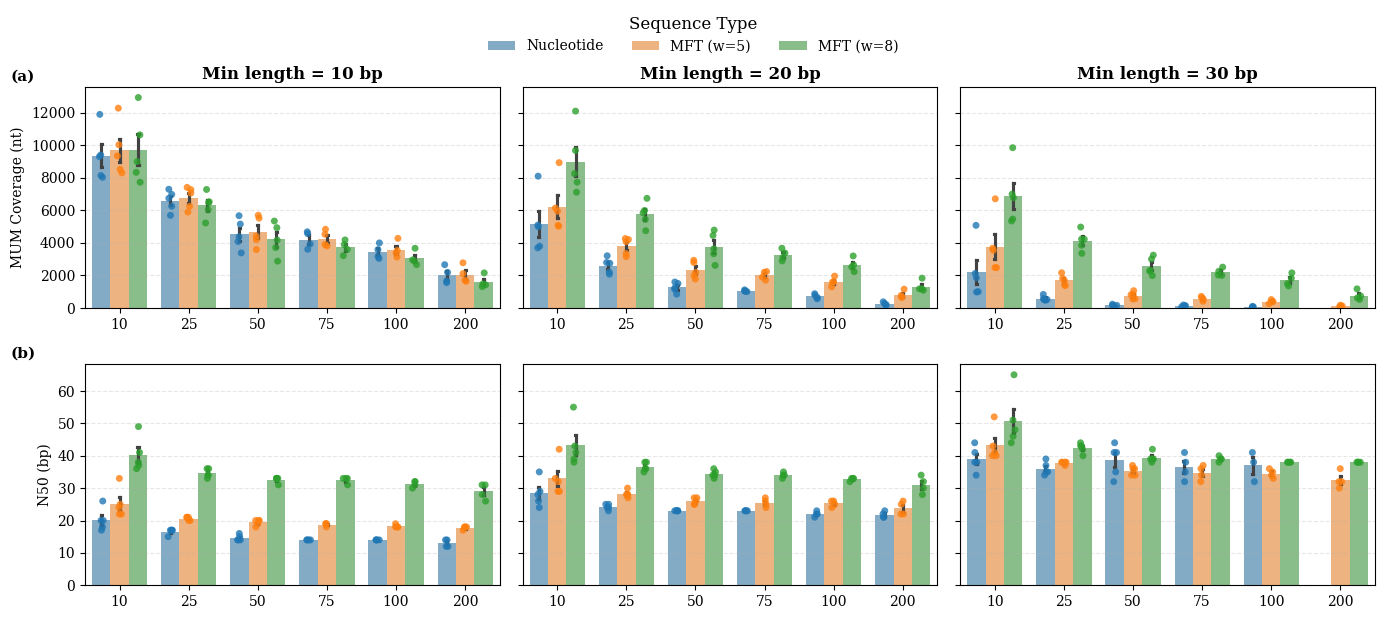

In [12]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)']
palette   = "tab10"

mum_metrics = [
    ('Cumulative MUM Length', 'MUM Coverage (nt)'),
    ('N50',                   'N50 (bp)'),
]
parsnp_metrics = [
    ('core_length', 'Parsnp Core\nCoverage (%)'),
    ('snps_length', 'Parsnp SNP\nBlock Length (bp)'),
    ('time_s',      'Parsnp Wall\nTime (s)'),
]
parsnp_metrics = []
min_lengths = [10, 20, 30]

# Pre-compute MUM summaries for each min length
summaries = {}
for min_len in min_lengths:
    sub = df_master[
        (df_master['Length'] >= min_len) &
        (df_master['Present_Count'] == df_master['n'])
    ]
    summaries[min_len] = (
        sub.groupby(['n', 'rep', 'Dataset'])
        .apply(
            lambda x: pd.Series({
                'Cumulative MUM Length': x['Length'].sum(),
                'N50':                   calculate_n50(x['Length'].values),
            }),
            include_groups=False,
        )
        .reset_index()
    )

n_mum_rows    = len(mum_metrics)
n_parsnp_rows = len(parsnp_metrics)
n_rows        = n_mum_rows + n_parsnp_rows

fig, axes = plt.subplots(n_rows, 3, figsize=(14, n_rows * 3), sharey='row')

for col_idx, min_len in enumerate(min_lengths):
    summary = summaries[min_len]

    for row_idx, (metric, ylabel) in enumerate(mum_metrics):
        ax = axes[row_idx, col_idx]
        sns.barplot(
            data=summary, x='n', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
        )
        sns.stripplot(
            data=summary, x='n', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, legend=False, alpha=0.8, dodge=True,
        )
        if row_idx == 0:
            ax.set_title(f'Min length = {min_len} bp', fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(ylabel if col_idx == 0 else '')
        ax.tick_params(axis='x')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if ax.get_legend():
            ax.get_legend().remove()

    for p_idx, (metric, ylabel) in enumerate(parsnp_metrics):
        row_idx = n_mum_rows + p_idx
        ax = axes[row_idx, col_idx]
        sns.barplot(
            data=parsnp_df, x='n', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
        )
        sns.stripplot(
            data=parsnp_df, x='n', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, legend=False, alpha=0.8, dodge=True,
        )
        ax.set_xlabel('Genomes ($n$)' if row_idx == n_rows - 1 else '')
        ax.set_ylabel(ylabel if col_idx == 0 else '')
        ax.tick_params(axis='x')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if ax.get_legend():
            ax.get_legend().remove()

row_labels = [chr(ord('a') + i) for i in range(n_rows)]
for row_idx in range(n_rows):
    axes[row_idx, 0].text(-0.12, 1.08, f'({row_labels[row_idx]})',
                          transform=axes[row_idx, 0].transAxes,
                          fontsize=11, fontweight='bold', va='top', ha='right')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04),
           ncol=4, frameon=False, title="Sequence Type")

plt.tight_layout()

plt.subplots_adjust(top=0.9)
plt.savefig('fig4_n_sweep.png', dpi=300, bbox_inches='tight')
plt.savefig('fig4_n_sweep.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
organisms = [
    ("Measles",    "/dodo/ab235/actual-final/measles"),
    ("SARS-CoV-2", "/dodo/ab235/actual-final/covid"),
    ("Adenovirus", "/dodo/ab235/actual-final/adenovirus"),
    ("Ebola",      "/dodo/ab235/actual-final/ebola"),
]

dataset_name_map_multi = {
    "nucleotide": "Nucleotide",
    "mft_w5":     "MFT (w=5)",
    "mft_w8":     "MFT (w=8)",
    "mft_w11":    "MFT (w=11)",
}

dataset_name_map_multi = {
    "nucleotide": "Nucleotide",
    "mft_w5":     "MFT (w=5)",
    "mft_w8":     "MFT (w=8)",
}

parsnp_all_rows = []
folder_re = re.compile(r"^n_(\d+)_rep(\d+)$")

for organism_name, parsnp_path in organisms:
    for folder in sorted(os.listdir(parsnp_path)):
        m = folder_re.match(folder)
        if not m:
            continue
        n_val = int(m.group(1))
        rep   = int(m.group(2))
        csv_path = os.path.join(parsnp_path, folder, "parsnp_summary_short.csv")
        if not os.path.exists(csv_path):
            continue
        tmp = pd.read_csv(csv_path)
        tmp["n"]        = n_val
        tmp["rep"]      = rep
        tmp["Organism"] = organism_name
        parsnp_all_rows.append(tmp)

parsnp_all_df = pd.concat(parsnp_all_rows, ignore_index=True)
parsnp_all_df["Dataset"] = parsnp_all_df["dataset"].map(dataset_name_map_multi)
parsnp_all_df = parsnp_all_df.drop(columns=["dataset"])
print(parsnp_all_df.shape)
parsnp_all_df


(480, 10)


,n,rep,core_pre,core_length,snps_pre,snps_length,fp_lcbs,time_s,Organism,Dataset
0,100,1,16.232541,15.792123,421,419,2,6.08,Measles,Nucleotide
1,100,1,38.976972,38.813389,1123,1121,1,6.37,Measles,MFT (w=5)
2,100,1,46.891909,46.149490,1426,1379,4,6.28,Measles,MFT (w=8)
3,100,1,31.414370,28.859947,1002,838,11,6.61,Measles,NaN
4,100,2,10.469360,9.267648,288,287,7,5.39,Measles,Nucleotide
...,...,...,...,...,...,...,...,...,...,...
475,75,4,79.054802,76.232924,1734,1347,12,5.02,Ebola,NaN
476,75,5,95.632681,95.632681,1418,1418,0,9.04,Ebola,Nucleotide
477,75,5,97.958753,97.958753,1515,1515,0,12.77,Ebola,MFT (w=5)
478,75,5,92.167308,89.783216,1628,1327,16,4.06,Ebola,MFT (w=8)


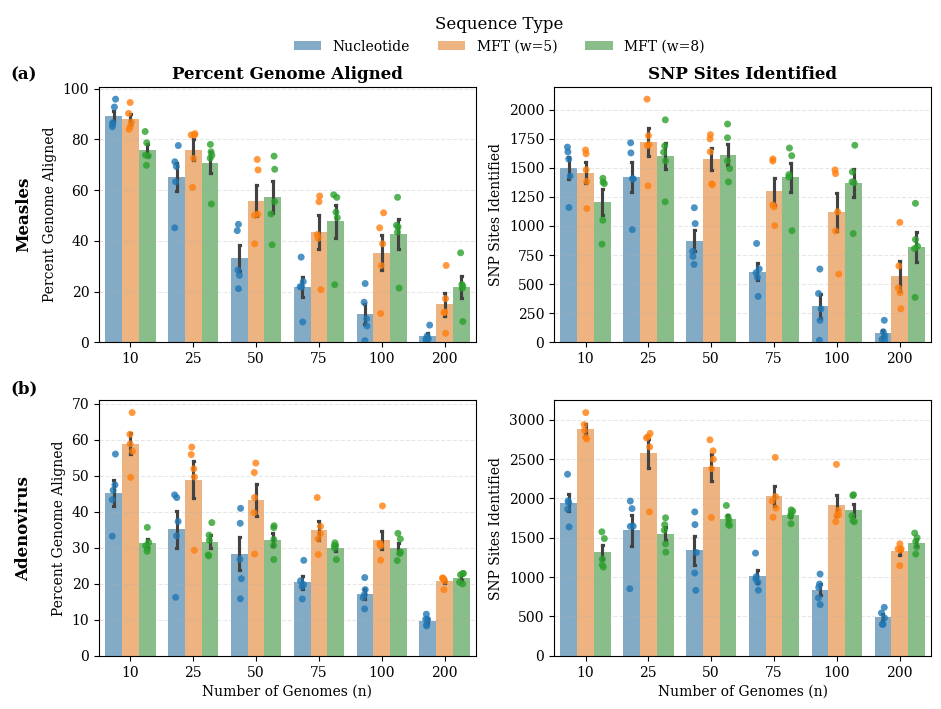

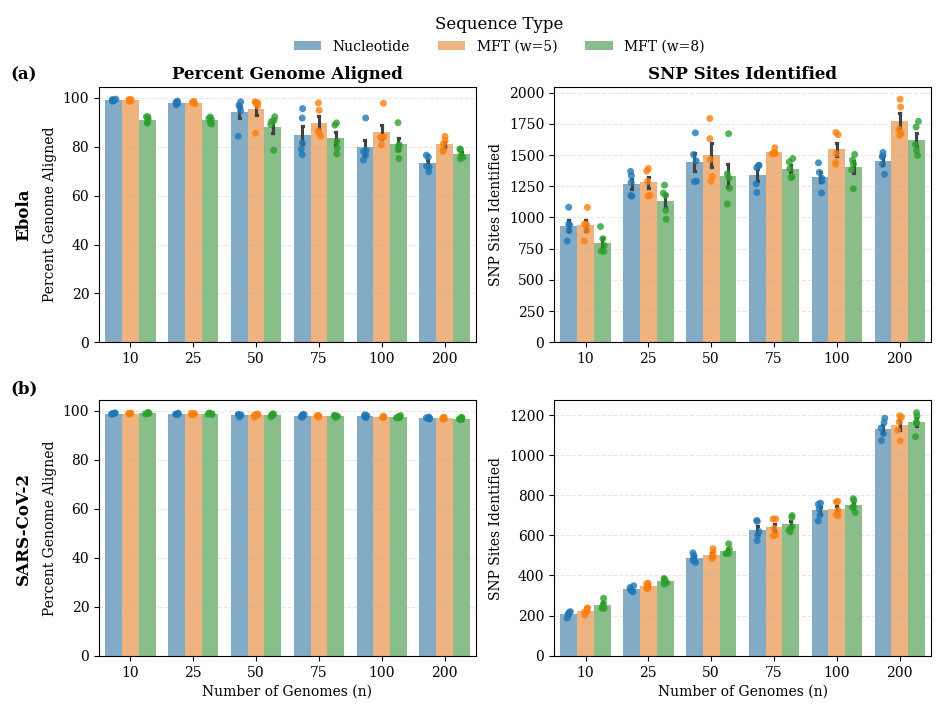

In [14]:
hue_order_multi = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)', 'MFT (w=11)']
hue_order_multi = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)']
metrics = [
    ('core_length', 'Percent Genome Aligned'),
    ('snps_length', 'SNP Sites Identified'),
]

def plot_organism_pair(organism_pair, filename_prefix):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    for row_idx, organism in enumerate(organism_pair):
        org_df = parsnp_all_df[parsnp_all_df['Organism'] == organism]

        for col_idx, (metric, ylabel) in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            sns.barplot(
                ax=ax,
                data=org_df, x='n', y=metric,
                hue='Dataset', hue_order=hue_order_multi,
                palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
            )
            sns.stripplot(
                ax=ax,
                data=org_df, x='n', y=metric,
                hue='Dataset', hue_order=hue_order_multi,
                palette=palette, legend=False, alpha=0.8, dodge=True,
            )
            if row_idx == 0:
                ax.set_title(ylabel, fontweight='bold')
            ax.set_ylabel(ylabel)
            ax.set_xlabel('Number of Genomes (n)' if row_idx == 1 else '')
            ax.tick_params(axis='x')
            ax.grid(axis='y', linestyle='--', alpha=0.3)
            if ax.get_legend():
                ax.get_legend().remove()

        # (a)/(b) label at top-left of each row
        row_label = chr(ord('a') + row_idx)
        axes[row_idx, 0].text(
            -0.2, 1.08, f'({row_label})',
            transform=axes[row_idx, 0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='center',
        )

        # Organism name rotated on the left
        axes[row_idx, 0].annotate(
            organism,
            xy=(-0.2, 0.5), xycoords='axes fraction',
            fontsize=12, fontweight='bold', va='center', ha='center',
            rotation=90, annotation_clip=False,
        )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.02),
               ncol=4, frameon=False, title="Sequence Type")

    plt.tight_layout()
    plt.subplots_adjust(top=0.90, left=0.15)
    plt.savefig(f'{filename_prefix}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{filename_prefix}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


plot_organism_pair(["Measles", "Adenovirus"], "MultiOrganismSubplots_MeaslesAdenovirus")
plot_organism_pair(["Ebola", "SARS-CoV-2"],  "MultiOrganismSubplots_EbolaSARSCoV2")


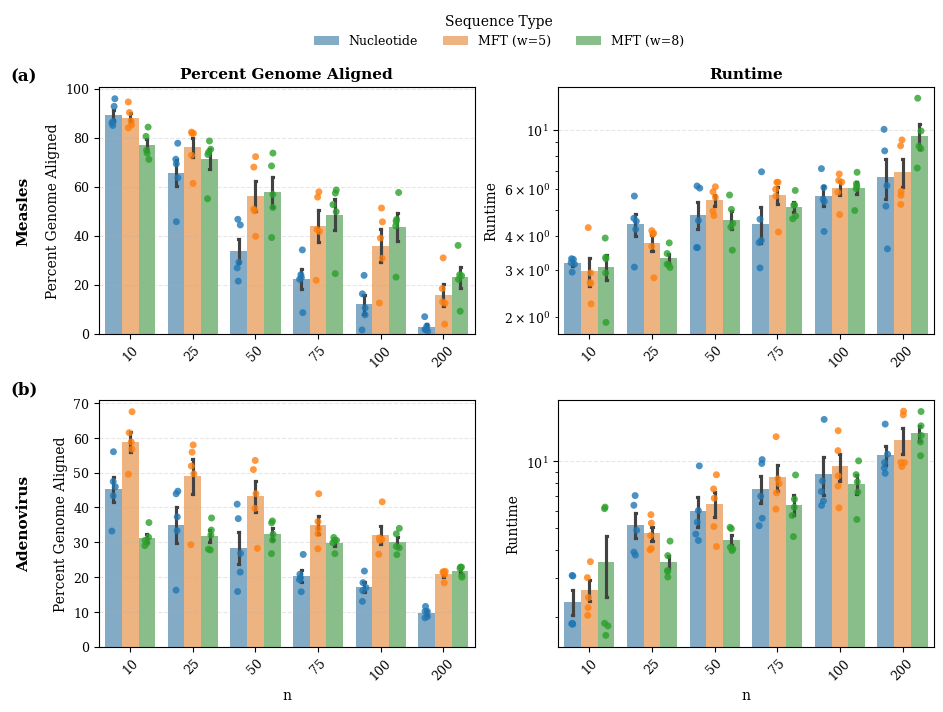

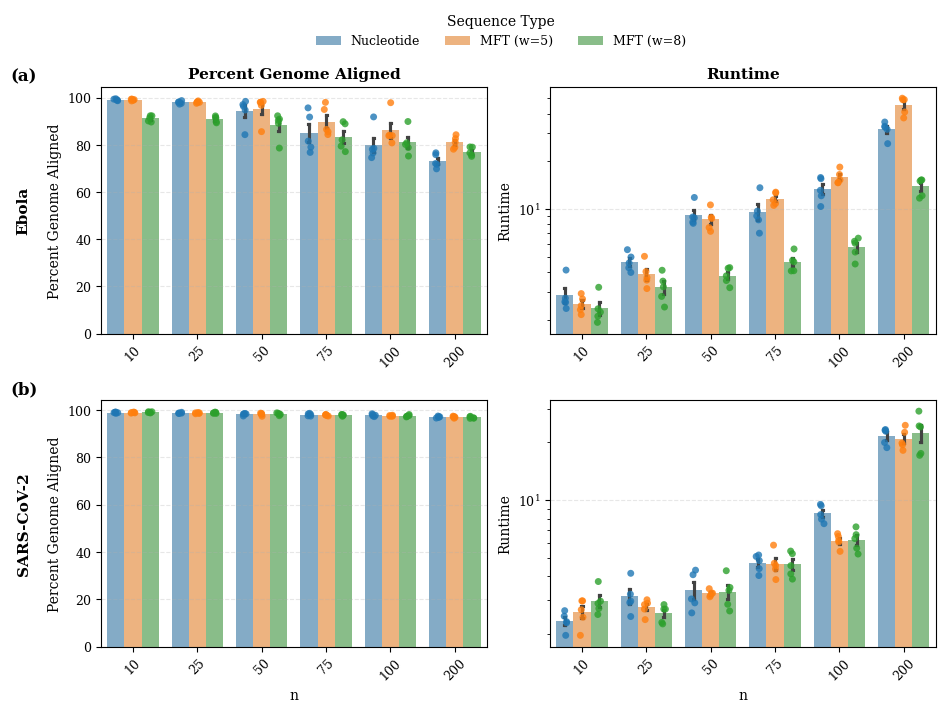

In [13]:
hue_order_multi = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)', 'MFT (w=11)']
hue_order_multi = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)']
metrics = [
    ('core_length', 'Percent Genome Aligned'),
    ('time_s', 'Runtime'),
]

def plot_organism_pair_timed(organism_pair, filename_prefix):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    for row_idx, organism in enumerate(organism_pair):
        org_df = parsnp_all_df[parsnp_all_df['Organism'] == organism]

        for col_idx, (metric, ylabel) in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            sns.barplot(
                ax=ax,
                data=org_df, x='n', y=metric,
                hue='Dataset', hue_order=hue_order_multi,
                palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
            )
            sns.stripplot(
                ax=ax,
                data=org_df, x='n', y=metric,
                hue='Dataset', hue_order=hue_order_multi,
                palette=palette, legend=False, alpha=0.8, dodge=True,
            )
            if row_idx == 0:
                ax.set_title(ylabel, fontweight='bold')
            ax.set_ylabel(ylabel)
            ax.set_xlabel('n' if row_idx == 1 else '')
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.3)
            if ax.get_legend():
                ax.get_legend().remove()
            if col_idx == 1:
                ax.set_yscale('log')

        # (a)/(b) label at top-left of each row
        row_label = chr(ord('a') + row_idx)
        axes[row_idx, 0].text(
            -0.2, 1.08, f'({row_label})',
            transform=axes[row_idx, 0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='center',
        )

        # Organism name rotated on the left
        axes[row_idx, 0].annotate(
            organism,
            xy=(-0.2, 0.5), xycoords='axes fraction',
            fontsize=11, fontweight='bold', va='center', ha='center',
            rotation=90, annotation_clip=False,
        )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.02),
               ncol=4, frameon=False, title="Sequence Type")

    plt.tight_layout()
    plt.subplots_adjust(top=0.90, left=0.15)
    plt.savefig(f'{filename_prefix}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{filename_prefix}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


plot_organism_pair_timed(["Measles", "Adenovirus"], "MultiOrganismSubplots_MeaslesAdenovirus_timed")
plot_organism_pair_timed(["Ebola", "SARS-CoV-2"],  "MultiOrganismSubplots_EbolaSARSCoV2_timed")

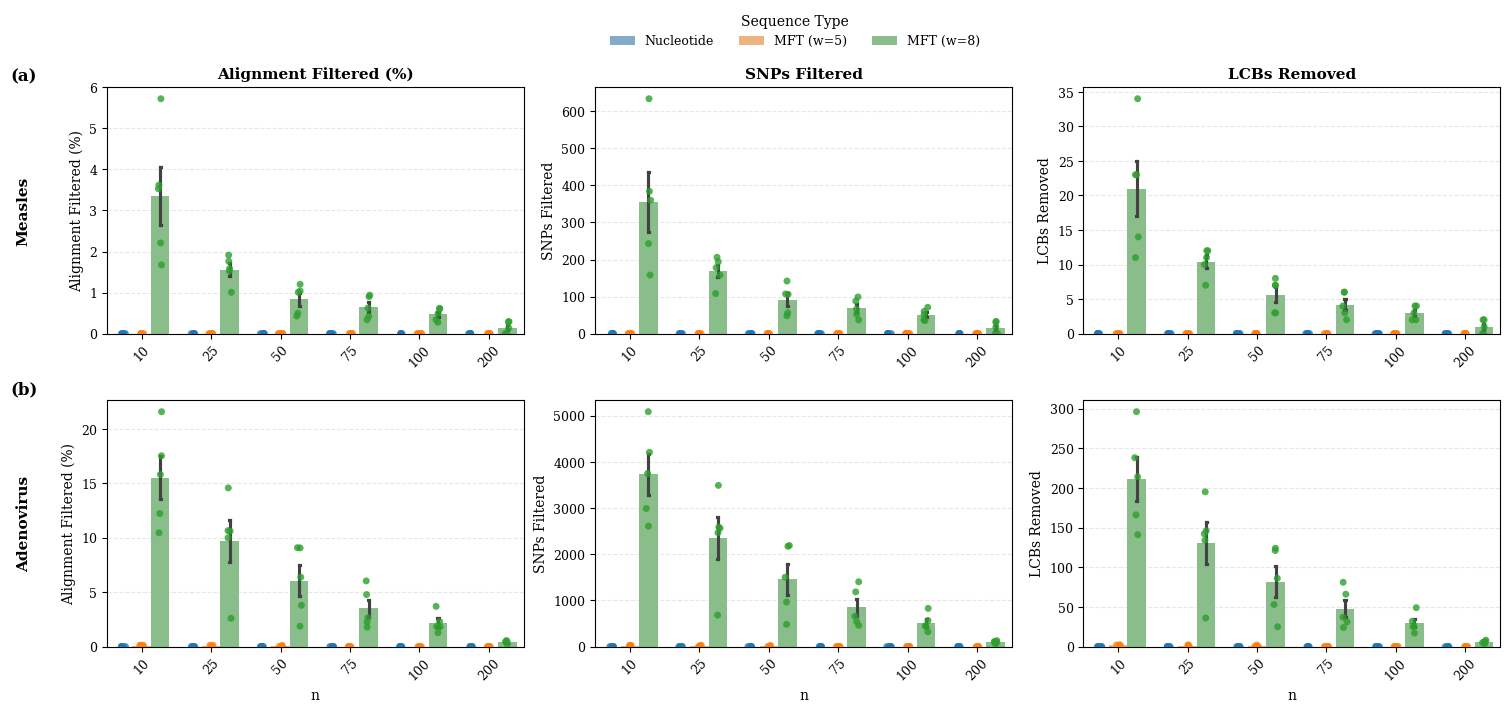

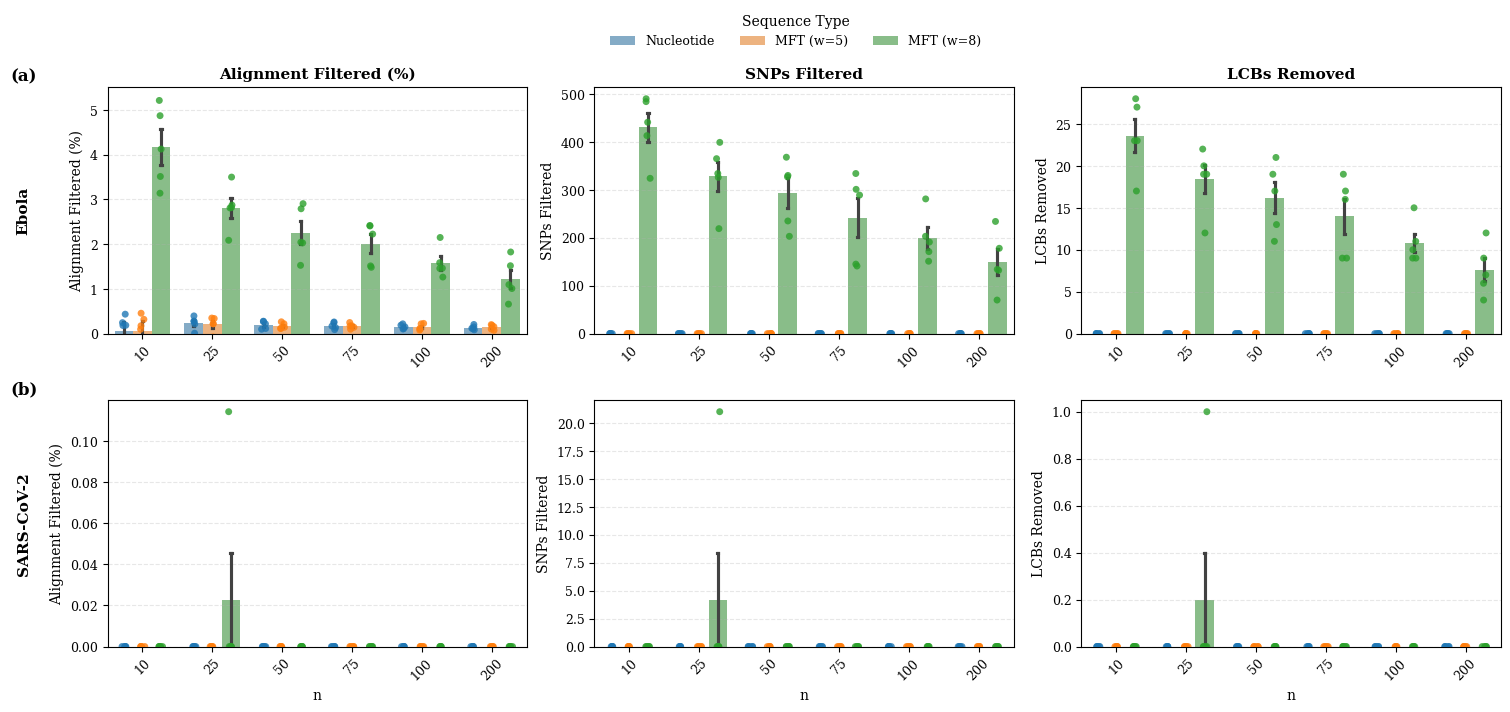

In [14]:
parsnp_all_df['fp_snps'] = parsnp_all_df['snps_pre'] - parsnp_all_df['snps_length']
parsnp_all_df['fp_core'] = parsnp_all_df['core_pre'] - parsnp_all_df['core_length']

fp_metrics = [
    ('fp_core', 'Alignment Filtered (%)'),
    ('fp_snps', 'SNPs Filtered'),
    ('fp_lcbs', 'LCBs Removed'),
]

def plot_organism_pair_fp(organism_pair, filename_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(16, 7))

    for row_idx, organism in enumerate(organism_pair):
        org_df = parsnp_all_df[parsnp_all_df['Organism'] == organism]

        for col_idx, (metric, ylabel) in enumerate(fp_metrics):
            ax = axes[row_idx, col_idx]
            sns.barplot(
                ax=ax,
                data=org_df, x='n', y=metric,
                hue='Dataset', hue_order=hue_order_multi,
                palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
            )
            sns.stripplot(
                ax=ax,
                data=org_df, x='n', y=metric,
                hue='Dataset', hue_order=hue_order_multi,
                palette=palette, legend=False, alpha=0.8, dodge=True,
            )
            if row_idx == 0:
                ax.set_title(ylabel, fontweight='bold')
            ax.set_ylim(bottom=0)
            ax.set_ylabel(ylabel)
            ax.set_xlabel('n' if row_idx == 1 else '')
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.3)
            if ax.get_legend():
                ax.get_legend().remove()

        row_label = chr(ord('a') + row_idx)
        axes[row_idx, 0].text(
            -0.2, 1.08, f'({row_label})',
            transform=axes[row_idx, 0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='center',
        )
        axes[row_idx, 0].annotate(
            organism,
            xy=(-0.2, 0.5), xycoords='axes fraction',
            fontsize=11, fontweight='bold', va='center', ha='center',
            rotation=90, annotation_clip=False,
        )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.02),
               ncol=4, frameon=False, title="Sequence Type")

    plt.tight_layout()
    plt.subplots_adjust(top=0.90, left=0.12)
    plt.savefig(f'{filename_prefix}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{filename_prefix}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


plot_organism_pair_fp(["Measles", "Adenovirus"], "FPSubplots_MeaslesAdenovirus")
plot_organism_pair_fp(["Ebola", "SARS-CoV-2"],  "FPSubplots_EbolaSARSCoV2")
